
# SI Code 01 (T0-shift) | Frequentist variance partitioning

The frequentist counterpart of the T0-shift revision. `SI_code1_PreProcessing_finalized.ipynb`
stays the **record of the original submission**: its §4 fits only the additive form, and
`fig6_ODR_regression_dilution.pdf` is the prior-elicitation figure for `beta_G23_crtp` /
`beta_NO3_crtp`. Nothing here touches it.

This notebook re-runs that §4 analysis with a switch for **where the non-thermal predictors
enter the curve**, so the submitted parameterization and the revision can be compared on
identical data, an identical fitting protocol, and identical diagnostics.

| | `parameterization='additive'` (submitted) | `parameterization='t0shift'` (revision) |
|---|---|---|
| mean | $\mu = b + \dfrac{1-b}{\left(1+e^{-k(T-T_0)}\right)^{1/\nu}} + \beta_{G23}g_{23} + \beta_{NO_3}\log_{10}[NO_3^-]$ | $T_0^{\text{eff}} = T_0 + \gamma_{G23}g_{23} + \gamma_{NO_3}\log_{10}[NO_3^-]$, &nbsp; $\mu = b + \dfrac{1-b}{\left(1+e^{-k(T-T_0^{\text{eff}})}\right)^{1/\nu}}$ |
| coefficients | $\beta_{G23}$, $\beta_{NO_3}$ | $\gamma_{G23}$, $\gamma_{NO_3}$ |
| units | Scaled RI per predictor unit | **°C** per predictor unit |
| sign | negative | positive |
| effective range | $[b+c,\; 1+c]$ — unbounded | $(b,\;1)$ — **bounded by construction** |
| Stan counterpart | `..._priorApprox_eiv.stan` | `..._priorApprox_eiv_t0shift.stan` |

Both go through the same three stages, so the two columns of every table are comparable:

1. **stage 1** — thermal curve on culture + mesocosm → the prior approximation;
2. **stage 2** — thermal curve re-optimised on core-tops inside stage 1 ± `t_reopt_n_sigma`;
3. **stage 3** — the non-thermal coefficients, by either
   `beta_fit='twostep'` (θ_T fixed at stage 2, coefficients fitted on the T-only residuals,
   with an ODR variant that carries the per-site predictor SEs) or
   `beta_fit='joint'` (θ_T and the coefficients optimised together).

The NO₃ gate (`0 < NO₃ < cutoff`) matches the Stan models in both forms.

**What this notebook does not do.** It does no preprocessing — it reads the finished
`ds_gridded_screened_global_compilation_finalized.csv` that `SI_code1` writes. Re-run
`SI_code1` first if the compilation has changed.

# 1. Setup

In [1]:

import os
import math
import warnings
warnings.filterwarnings('ignore')

import numpy as np
np.random.seed(42)
import pandas as pd

from scipy.optimize import curve_fit
from scipy.odr import ODR, Model, RealData
from scipy.stats import spearmanr

import matplotlib as mpl
import matplotlib.pyplot as plt

from matplotlib import font_manager
try:
    font_manager.findfont('TeX Gyre Heros')
    mpl.rcParams.update({'font.sans-serif': 'TeX Gyre Heros'})
except Exception:
    pass
mpl.rcParams.update({'font.weight': 'normal',
                     'axes.labelweight': 'normal',
                     'axes.titleweight': 'normal',
                     'pdf.fonttype': 42,
                     'ps.fonttype': 42})

from TEXAS.stats import f_test
import TEXAS
print('TEXAS', TEXAS.__version__)

TEXAS 0.2.6


In [2]:

from pathlib import Path

IN_DOCKER = Path('/home/micromamba/app').exists()
if IN_DOCKER:
    local_github_path = Path('/home/micromamba/app')
else:
    local_github_path = Path.home() / 'Documents/GitHub/TEXAS'
print(local_github_path)

### Regression dataset compilation --- written by SI_code1_PreProcessing_finalized.ipynb
fpath = os.path.join(local_github_path, 'data/spreadsheets')
fname = r'ds_gridded_screened_global_compilation_finalized.csv'

gridded_combined_df = pd.read_csv(os.path.join(fpath, fname))
print(gridded_combined_df.shape)
gridded_combined_df['datatype'].value_counts()

/home/rrattan/Documents/GitHub/TEXAS
(1576, 49)


datatype
coretop     1513
culture       55
mesocosm       8
Name: count, dtype: int64


# 2. The dual-parameterization fitter

One function, one switch. Everything below — tables, the β↔γ translation, the figure —
reads its return dict.

The default coefficient bounds are **wider and symmetric** relative to Stan's
(`beta ∈ [-1, 0]`, `gamma_G23 ∈ [0, 5]`, `gamma_NO3 ∈ [0, 20]`) so a frequentist optimum is
never pinned at zero by the bound itself. Pass `coef_bounds=` to mirror Stan exactly.

In [3]:
import math
import numpy as np
import pandas as pd
from scipy.optimize import curve_fit
from scipy.odr import ODR, Model, RealData
from TEXAS.stats import f_test


# ── the two mean functions ───────────────────────────────────────────────────

def _glf(T, t0, b, k, v):
    z = np.clip(-k * (np.asarray(T, dtype=float) - t0), -700.0, 700.0)
    return b + (1.0 - b) / np.power(1.0 + np.exp(z), 1.0 / v)


def _dglf_dT(T, t0, b, k, v):
    """f'(T) — the local thermal sensitivity, in RI per degC.

    Needed to translate between the two parameterizations: a gamma shift of T0
    moves the response by roughly -f'(T)*gamma*x, so beta ~= -f'(T)*gamma.
    f' varies ~6x over the sampled range, so any such conversion is local.
    """
    z = np.clip(-k * (np.asarray(T, dtype=float) - t0), -700.0, 700.0)
    e = np.exp(z)
    return (1.0 - b) * (k / v) * e * np.power(1.0 + e, -1.0 / v - 1.0)


def mu_additive(T, g23, logno3, t0, b, k, v, cG=0.0, cN=0.0):
    return _glf(T, t0, b, k, v) + cG * g23 + cN * logno3


def mu_t0shift(T, g23, logno3, t0, b, k, v, cG=0.0, cN=0.0):
    return _glf(T, t0 + cG * g23 + cN * logno3, b, k, v)


MU = {"additive": mu_additive, "t0shift": mu_t0shift}

# Coefficient names + default free-fit bounds per parameterization.
# The Stan models bound beta in [-1, 0] and gamma in [0, 5] / [0, 20]; here the
# bounds are widened symmetrically so the frequentist optimum is never pinned
# at zero by construction (pass coef_bounds= to mirror Stan exactly).
COEF = {
    "additive": dict(
        sym=("beta_G23", "beta_NO3"), unit=("RI / unit", "RI / log10-unit"),
        lo=(-1.0, -1.0), hi=(1.0, 1.0), p0=(-0.006, -0.03),
    ),
    "t0shift": dict(
        sym=("gamma_G23", "gamma_NO3"), unit=("degC / unit", "degC / log10-unit"),
        lo=(-5.0, -20.0), hi=(5.0, 20.0), p0=(0.2, 1.6),
    ),
}


# ── formatting helpers (same conventions as SI_code1) ────────────────────────

def _n_decimals(scale):
    if not math.isfinite(scale) or scale <= 0:
        return 3
    mag = math.floor(math.log10(abs(scale)))
    first = int(abs(scale) / 10 ** mag)
    return max(0, 1 - mag) if first <= 3 else max(0, -mag)


def _fmt_stat(m, s):
    if not math.isfinite(s) or s <= 0:
        return f"{m:.3g}"
    n = _n_decimals(s)
    return f"{round(m, n):.{n}f} +/- {round(s, n):.{n}f}"


def _fmt_r2(r2):
    n = min(_n_decimals(1 - r2), 3)
    return f"{round(r2, n):.{n}f}"


def _fmt_rmse(x):
    return f"{x:.4f}"


def _fmt_dr2(d):
    return f"{d:+.4f}"


def _fmt_p(p):
    return "<1e-16" if p < 1e-16 else f"{p:.2e}"


def _fmt_coef(v, ci):
    if v is None or not math.isfinite(v):
        return "-"
    n = _n_decimals(ci) if (ci is not None and math.isfinite(ci) and ci > 0) else 4
    return f"{round(v, n):.{n}f} +/- {round(ci, n):.{n}f}" if ci is not None else f"{v:.4g}"


def _stats(y, yhat):
    r = y - yhat
    rss = float(np.sum(r ** 2))
    return (float(1 - rss / np.sum((y - y.mean()) ** 2)),
            float(np.sqrt(np.mean(r ** 2))), rss)


def _bootstrap_se(fn, X, y, p0, bounds, n_boot, seed):
    rng = np.random.default_rng(seed)
    out = []
    for _ in range(n_boot):
        i = rng.integers(0, len(y), len(y))
        try:
            p, _ = curve_fit(fn, X[i], y[i], p0=p0, bounds=bounds, max_nfev=10000)
            out.append(p)
        except (RuntimeError, ValueError):
            pass
    out = np.array(out)
    if len(out) < 10:
        return np.full(len(p0), np.nan)
    return out.std(axis=0)


# ── main ─────────────────────────────────────────────────────────────────────

def run_variance_partitioning_dual(
    gridded_combined_df,
    *,
    parameterization="additive",
    beta_fit="twostep",
    x_param="SST",
    y_param="scaledRI_cren3",
    g23_col="gdgt23ratio",
    no3_col="no3_sf2tc_avg",
    no3_threshold=1.0,
    no3_fill_value=10.0,
    gdgt23_se_col=None,
    no3_se_col=None,
    sd_proxyObs_col=None,
    sigma_ri_analytical=0.03,
    no3_se_floor=1e-3,
    no3_se_cap=1.0,
    t_reopt_n_sigma=3.0,
    coef_bounds=None,
    n_boot=500,
    boot_seed=42,
    verbose=True,
):
    if parameterization not in MU:
        raise ValueError("parameterization must be 'additive' or 't0shift'")
    if beta_fit not in ("twostep", "joint"):
        raise ValueError("beta_fit must be 'twostep' or 'joint'")

    mu_fn = MU[parameterization]
    spec = COEF[parameterization]
    symG, symN = spec["sym"]
    lo_c, hi_c = (spec["lo"], spec["hi"]) if coef_bounds is None else coef_bounds
    p0_c = spec["p0"]

    # ── data ─────────────────────────────────────────────────────────────────
    df = gridded_combined_df.copy()
    df[no3_col] = [no3_fill_value if (dt != "coretop" and np.isnan(x)) else x
                   for x, dt in zip(df[no3_col], df["datatype"])]
    df = df.dropna(subset=[x_param, y_param, g23_col, no3_col])
    df = df.sort_values("datatype",
                        key=lambda s: s.map({"coretop": 0, "mesocosm": 1, "culture": 2})
                        ).reset_index(drop=True)

    ct = df["datatype"] == "coretop"
    T = df.loc[ct, x_param].to_numpy(float)
    G = df.loc[ct, g23_col].to_numpy(float)
    NO3 = df.loc[ct, no3_col].to_numpy(float)
    Y = df.loc[ct, y_param].to_numpy(float)
    n = len(Y)

    gate = (NO3 > 0) & (NO3 < no3_threshold)
    LN = np.where(gate, np.log10(np.clip(NO3, 1e-9, None)), 0.0)   # gated log10 NO3
    n_no3 = int(gate.sum())

    # ── stage 1: culture + mesocosm T-curve ──────────────────────────────────
    cm = df["datatype"].isin(["culture", "mesocosm"])
    Tcm, Ycm = df.loc[cm, x_param].to_numpy(float), df.loc[cm, y_param].to_numpy(float)
    b_cm = ([0, 0, 0, 0], [40, 0.5, 1, 5])
    popt_cm, pcov_cm = curve_fit(lambda t, t0, b, k, v: _glf(t, t0, b, k, v),
                                 Tcm, Ycm, p0=[20, 0.1, 0.1, 0.1], bounds=b_cm)
    r2_cm, rmse_cm, _ = _stats(Ycm, _glf(Tcm, *popt_cm))
    bse_cm = (_bootstrap_se(lambda t, t0, b, k, v: _glf(t, t0, b, k, v),
                            Tcm, Ycm, list(popt_cm), b_cm, n_boot, boot_seed)
              if n_boot > 0 else np.sqrt(np.diag(pcov_cm)))

    # ── stage 2: T-only re-optimised on coretop, inside popt_cm +/- n sigma ──
    g_lo, g_hi = np.array([10., 0., 0., 0.]), np.array([50., 0.5, 0.5, 5.])
    if t_reopt_n_sigma is not None and np.all(np.isfinite(bse_cm)):
        s = np.asarray(bse_cm) * t_reopt_n_sigma
        lo_T = np.clip(np.asarray(popt_cm) - s, g_lo, g_hi - 1e-6)
        hi_T = np.clip(np.asarray(popt_cm) + s, g_lo + 1e-6, g_hi)
    else:
        lo_T, hi_T = g_lo, g_hi

    X = np.column_stack([T, G, LN])

    def _f_T(Xa, t0, b, k, v):
        return mu_fn(Xa[:, 0], Xa[:, 1], Xa[:, 2], t0, b, k, v)

    popt_T, pcov_T = curve_fit(_f_T, X, Y, p0=list(popt_cm), bounds=(lo_T, hi_T))
    pred_T = _f_T(X, *popt_T)
    resid_T = Y - pred_T
    r2_base, rmse_base, rss_base = _stats(Y, pred_T)
    k_base = 4
    bse_T = (_bootstrap_se(_f_T, X, Y, list(popt_T), (lo_T, hi_T), n_boot, boot_seed)
             if n_boot > 0 else np.sqrt(np.diag(pcov_T)))

    # ── sy for ODR: analytical (+) process noise in quadrature (Stan total_sd) ──
    if sd_proxyObs_col is not None and sd_proxyObs_col in df.columns:
        sd_obs = df.loc[ct, sd_proxyObs_col].to_numpy(float)
        sd_obs = np.where(np.isfinite(sd_obs) & (sd_obs > 0), sd_obs, sigma_ri_analytical)
    else:
        sd_obs = np.full(n, sigma_ri_analytical)
    mean_sd_obs = float(sd_obs.mean())
    sigma_proc = mean_sd_obs * np.sqrt(max(0.0, 1.0 - r2_base))
    sy = np.sqrt(sd_obs ** 2 + sigma_proc ** 2)

    sx_G = None
    if gdgt23_se_col is not None and gdgt23_se_col in df.columns:
        sx_G = df.loc[ct, gdgt23_se_col].to_numpy(float)
        sx_G = np.where(np.isfinite(sx_G) & (sx_G > 0), sx_G, no3_se_cap)
    sx_N = None
    if no3_se_col is not None and no3_se_col in df.columns:
        se_lin = df.loc[ct, no3_se_col].to_numpy(float)
        with np.errstate(divide="ignore", invalid="ignore"):
            s = se_lin / (NO3 * np.log(10))          # delta method -> log10 scale
        s = np.where(np.isfinite(s) & (s > 0), s, no3_se_cap)
        sx_N = np.clip(s, no3_se_floor, no3_se_cap)
    do_odr = (sx_G is not None) or (sx_N is not None)

    # ── stage 3 ──────────────────────────────────────────────────────────────
    # Each entry: (label, use_G, use_N)
    variants = [("G23", True, False), ("NO3", False, True), ("Both", True, True)]
    ols, odr = {}, {}

    if beta_fit == "joint":
        for lab, uG, uN in variants:
            free = [i for i, u in enumerate((uG, uN)) if u]

            def _f(Xa, t0, b, k, v, *cs, _free=tuple(free)):
                c = [0.0, 0.0]
                for j, i in enumerate(_free):
                    c[i] = cs[j]
                return mu_fn(Xa[:, 0], Xa[:, 1], Xa[:, 2], t0, b, k, v, *c)

            p0 = list(popt_T) + [p0_c[i] for i in free]
            bl = list(lo_T) + [lo_c[i] for i in free]
            bh = list(hi_T) + [hi_c[i] for i in free]
            popt, pcov = curve_fit(_f, X, Y, p0=p0, bounds=(bl, bh), max_nfev=20000)
            pred = _f(X, *popt)
            r2, rmse, rss = _stats(Y, pred)
            se = np.sqrt(np.diag(pcov))
            cG = popt[4 + free.index(0)] if uG else None
            cN = popt[4 + free.index(1)] if uN else None
            sG = se[4 + free.index(0)] if uG else None
            sN = se[4 + free.index(1)] if uN else None
            ols[lab] = dict(r2=r2, rmse=rmse, rss=rss, cG=cG, cN=cN,
                            ciG=None if sG is None else 1.96 * sG,
                            ciN=None if sN is None else 1.96 * sN,
                            popt=popt, pred=pred, offset=0.0)
    else:
        # theta_T fixed; fit coefficients (+ a nuisance offset) on the residuals.
        # additive : offset is an intercept on RI    (mu -> mu + c)
        # t0shift : offset is a shift of T0         (T0 -> T0 + dt0), which keeps
        #            the bounded guarantee intact
        def _resid_model(p, xrows, uG, uN):
            off = p[0]
            c = [0.0, 0.0]
            j = 1
            if uG:
                c[0] = p[j]; j += 1
            if uN:
                c[1] = p[j]
            t0, b, k, v = popt_T
            if parameterization == "additive":
                return c[0] * xrows[1] + c[1] * xrows[2] + off
            return (_glf(xrows[0], t0 + off + c[0] * xrows[1] + c[1] * xrows[2], b, k, v)
                    - _glf(xrows[0], t0, b, k, v))

        for lab, uG, uN in variants:
            rows = np.vstack([T, G, LN])
            p0 = [0.0] + [p0_c[i] for i, u in enumerate((uG, uN)) if u]
            bl = [-np.inf] + [lo_c[i] for i, u in enumerate((uG, uN)) if u]
            bh = [np.inf] + [hi_c[i] for i, u in enumerate((uG, uN)) if u]

            popt, pcov = curve_fit(
                lambda _x, *p: _resid_model(p, rows, uG, uN),
                np.arange(n), resid_T, p0=p0, bounds=(bl, bh), max_nfev=20000)
            se = np.sqrt(np.diag(pcov))
            pred = pred_T + _resid_model(popt, rows, uG, uN) if parameterization == "additive" \
                else _glf(T, popt_T[0] + popt[0]
                          + (popt[1] if uG else 0.0) * G
                          + (popt[-1] if uN else 0.0) * LN,
                          popt_T[1], popt_T[2], popt_T[3])
            r2, rmse, rss = _stats(Y, pred)
            idx = 1
            cG = popt[idx] if uG else None
            ciG = 1.96 * se[idx] if uG else None
            if uG:
                idx += 1
            cN = popt[idx] if uN else None
            ciN = 1.96 * se[idx] if uN else None
            ols[lab] = dict(r2=r2, rmse=rmse, rss=rss, cG=cG, cN=cN, ciG=ciG, ciN=ciN,
                            popt=list(popt_T) + [c for c in (cG, cN) if c is not None],
                            pred=pred, offset=float(popt[0]))

            # ── ODR counterpart ──────────────────────────────────────────────
            if not do_odr:
                continue
            if (uG and sx_G is None) or (uN and sx_N is None):
                continue
            xr_ = [T, G, LN]
            sxr = [np.full(n, 1e-6),
                   sx_G if sx_G is not None else np.full(n, no3_se_cap),
                   np.where(gate, sx_N, 1e6) if sx_N is not None else np.full(n, no3_se_cap)]
            keep = [0] if parameterization == "t0shift" else []
            if uG:
                keep.append(1)
            if uN:
                keep.append(2)
            Xo = np.vstack([xr_[i] for i in keep])
            SXo = np.vstack([sxr[i] for i in keep])
            pos = {i: j for j, i in enumerate(keep)}

            def _odr_model(p, x, _uG=uG, _uN=uN, _pos=pos):
                rows_ = [None, None, None]
                for i, j in _pos.items():
                    rows_[i] = x[j] if x.ndim > 1 else x
                if rows_[0] is None:
                    rows_[0] = T
                if rows_[1] is None:
                    rows_[1] = np.zeros_like(rows_[0])
                if rows_[2] is None:
                    rows_[2] = np.zeros_like(rows_[0])
                return _resid_model(p, rows_, _uG, _uN)

            res = ODR(RealData(Xo if Xo.shape[0] > 1 else Xo[0], resid_T,
                               sx=SXo if SXo.shape[0] > 1 else SXo[0], sy=sy),
                      Model(_odr_model), beta0=list(popt)).run()
            po, seo = res.beta, res.sd_beta
            predo = (pred_T + _resid_model(po, np.vstack([T, G, LN]), uG, uN)
                     if parameterization == "additive"
                     else _glf(T, popt_T[0] + po[0]
                               + (po[1] if uG else 0.0) * G
                               + (po[-1] if uN else 0.0) * LN,
                               popt_T[1], popt_T[2], popt_T[3]))
            r2o, rmseo, _ = _stats(Y, predo)
            i2 = 1
            oG = po[i2] if uG else None
            oGse = seo[i2] if uG else None
            if uG:
                i2 += 1
            oN = po[i2] if uN else None
            oNse = seo[i2] if uN else None
            odr[lab] = dict(r2=r2o, rmse=rmseo, cG=oG, cN=oN,
                            ciG=None if oGse is None else 1.96 * oGse,
                            ciN=None if oNse is None else 1.96 * oNse,
                            pred=predo, offset=float(po[0]))

    F, P = {}, {}
    for lab, extra in (("G23", 1), ("NO3", 1), ("Both", 2)):
        F[lab], P[lab] = f_test(rss_base, ols[lab]["rss"], k_base, k_base + extra, n)

    uniq_G = ols["Both"]["r2"] - ols["NO3"]["r2"]
    uniq_N = ols["Both"]["r2"] - ols["G23"]["r2"]

    # ── boundedness diagnostic (the reviewer's question) ─────────────────────
    bd = _boundedness(parameterization, popt_T, ols["Both"], G, LN, gate, T)

    out = dict(
        parameterization=parameterization, beta_fit=beta_fit, n_coretop=n,
        n_no3=n_no3, no3_threshold=no3_threshold,
        popt_culmeso=popt_cm, bse_culmeso=bse_cm, r2_culmeso=r2_cm, rmse_culmeso=rmse_cm,
        popt_T=popt_T, bse_T=bse_T, r2_base=r2_base, rmse_base=rmse_base, rss_base=rss_base,
        resid_T=resid_T, pred_T=pred_T,
        T=T, g23=G, log_no3=LN, no3=NO3, y=Y, no3_gate=gate,
        ols=ols, odr=odr, F=F, p=P,
        unique_variance=dict(g23=uniq_G, no3=uniq_N),
        mean_sd_proxyObs=mean_sd_obs, sigma_proc_est=sigma_proc, sy=sy,
        boundedness=bd, coef_names=(symG, symN), coef_units=spec["unit"],
    )
    if verbose:
        _print_tables(out)
    return out


def _boundedness(par, popt_T, best, G, LN, gate, T):
    """Effective response range of the fitted +Both model — the claim to show."""
    t0, b, k, v = popt_T
    cG = best["cG"] or 0.0
    cN = best["cN"] or 0.0
    off = best.get("offset", 0.0)
    mu_pts = (MU[par](T, G, LN, t0 + (off if par == "t0shift" else 0.0), b, k, v, cG, cN)
              + (off if par == "additive" else 0.0))
    grid = np.linspace(-2, 40, 400)
    if par == "additive":
        c = cG * G + cN * LN + off
        lo_as, hi_as = b + c.min(), 1.0 + c.max()
        frac_over = float(np.mean(1.0 + c > 1.0))
        frac_under = float(np.mean(b + c < 0.0))
        # response over the T grid at the extreme corrections
        curve_lo = _glf(grid, t0, b, k, v) + c.min()
        curve_hi = _glf(grid, t0, b, k, v) + c.max()
    else:
        lo_as, hi_as = b, 1.0
        frac_over = frac_under = 0.0
        t0e = t0 + off + cG * G + cN * LN
        curve_lo = _glf(grid, t0e.max(), b, k, v)
        curve_hi = _glf(grid, t0e.min(), b, k, v)
    return dict(
        mu_min_at_data=float(mu_pts.min()), mu_max_at_data=float(mu_pts.max()),
        asym_lo=float(lo_as), asym_hi=float(hi_as),
        frac_upper_gt_1=frac_over, frac_lower_lt_0=frac_under,
        curve_min=float(min(curve_lo.min(), curve_hi.min())),
        curve_max=float(max(curve_lo.max(), curve_hi.max())),
        grid=grid, curve_lo=curve_lo, curve_hi=curve_hi, mu_at_data=mu_pts,
    )


def _print_tables(r):
    W = 112
    symG, symN = r["coef_names"]
    uG, uN = r["coef_units"]
    print("=" * W)
    print(f"VARIANCE PARTITIONING - coretop only (n={r['n_coretop']})")
    print(f"  parameterization : {r['parameterization']}"
          f"   ({'mu + beta*x' if r['parameterization']=='additive' else 'T0 + gamma*x, bounded by construction'})")
    print(f"  coefficient fit  : {r['beta_fit']}"
          f"   |  NO3 gate: 0 < NO3 < {r['no3_threshold']} umol/L (n={r['n_no3']})")
    print("=" * W)
    print(f"{'Model':<26} {'R2':>8} {'dR2':>9} {symG:>22} {symN:>22} {'RMSE':>8} {'F':>7} {'p':>10}")
    print("-" * W)
    print(f"{'CulMeso T (stage 1)':<26} {_fmt_r2(r['r2_culmeso']):>8} {'-':>9} {'-':>22} {'-':>22} "
          f"{_fmt_rmse(r['rmse_culmeso']):>8} {'-':>7} {'-':>10}")
    print(f"{'Coretop T (baseline)':<26} {_fmt_r2(r['r2_base']):>8} {'-':>9} {'-':>22} {'-':>22} "
          f"{_fmt_rmse(r['rmse_base']):>8} {'-':>7} {'-':>10}")
    for lab, name in (("G23", "  + GDGT-2/3"), ("NO3", "  + NO3"), ("Both", "  + Both")):
        d = r["ols"][lab]
        print(f"{name + ' (OLS)':<26} {_fmt_r2(d['r2']):>8} {_fmt_dr2(d['r2']-r['r2_base']):>9} "
              f"{_fmt_coef(d['cG'], d['ciG']):>22} {_fmt_coef(d['cN'], d['ciN']):>22} "
              f"{_fmt_rmse(d['rmse']):>8} {r['F'][lab]:>7.0f} {_fmt_p(r['p'][lab]):>10}")
        if lab in r["odr"]:
            o = r["odr"][lab]
            print(f"{name + ' (ODR)':<26} {_fmt_r2(o['r2']) + '+':>8} {_fmt_dr2(o['r2']-r['r2_base']):>9} "
                  f"{_fmt_coef(o['cG'], o['ciG']):>22} {_fmt_coef(o['cN'], o['ciN']):>22} "
                  f"{_fmt_rmse(o['rmse']):>8} {'-':>7} {'-':>10}")
    print("-" * W)
    print(f"  units: {symG} in {uG};  {symN} in {uN}")
    print(f"  Unique GDGT-2/3 : {r['unique_variance']['g23']:+.4f}  ({100*r['unique_variance']['g23']:.2f} %)")
    print(f"  Unique NO3      : {r['unique_variance']['no3']:+.4f}  ({100*r['unique_variance']['no3']:.2f} %)")
    if r["odr"]:
        print(f"  ODR sy: analytical {r['mean_sd_proxyObs']:.4f} (+) process {r['sigma_proc_est']:.4f} in quadrature")
        print("  + R2 from vertical residuals; ODR minimises orthogonal distance - not directly comparable.")
    elif r["beta_fit"] == "joint":
        print("  no ODR rows: ODR is a two-step estimator here (it regresses the T-only")
        print("  residuals), so it has no counterpart when theta_T is fitted jointly.")
        print("  Use beta_fit='twostep' for the errors-in-variables comparison.")

    print()
    print("=" * W)
    print(f"T-CURVE PARAMETERS  (bootstrap 1 sigma)")
    print("=" * W)
    print(f"{'Param':<7} {'CulMeso (stage 1)':<28} {'Coretop T-only (stage 2)':<28} {'delta'}")
    print("-" * W)
    for i, nm in enumerate(["T0", "b", "k", "v"]):
        print(f"  {nm:<5} {_fmt_stat(r['popt_culmeso'][i], r['bse_culmeso'][i]):<28} "
              f"{_fmt_stat(r['popt_T'][i], r['bse_T'][i]):<28} {r['popt_T'][i]-r['popt_culmeso'][i]:+.3g}")

    b = r["boundedness"]
    print()
    print("=" * W)
    print("BOUNDEDNESS OF THE FITTED +Both MODEL")
    print("=" * W)
    print(f"  effective asymptotes                 : [{b['asym_lo']:.3f}, {b['asym_hi']:.3f}]")
    print(f"  mean response at the calibration pts : [{b['mu_min_at_data']:.3f}, {b['mu_max_at_data']:.3f}]")
    print(f"  mean response over T in [-2, 40] degC: [{b['curve_min']:.3f}, {b['curve_max']:.3f}]")
    print(f"  coretops with effective upper > 1    : {100*b['frac_upper_gt_1']:.1f} %")
    print(f"  coretops with effective lower < 0    : {100*b['frac_lower_lt_0']:.1f} %")
    print("=" * W)


# ── beta <-> gamma conversion and side-by-side comparison ────────────────────

def convert_coefficients(res_add, res_bnd, estimator="ols", variant="Both"):
    """Translate each parameterization's coefficients into the other's units.

    beta ~= -f'(T) * gamma, with f' evaluated at the mean T of the sites the
    term actually applies to (all coretops for G2/3; the gated subset for NO3).
    Because f' varies ~6x over the sampled range this is a LOCAL linearisation,
    not an identity — it is here to show the two fits agree in magnitude and to
    justify the prior scales in the T0-shift Stan model, nothing more.
    """
    t0, b, k, v = res_add["popt_T"]
    T = res_add["T"]
    gate = res_add["no3_gate"]
    fp_all = float(np.mean(_dglf_dT(T, t0, b, k, v)))
    fp_no3 = float(np.mean(_dglf_dT(T[gate], t0, b, k, v)))

    a = res_add[estimator][variant]
    g = res_bnd[estimator][variant]
    rows = []
    for name, ba, ga, fp in (("GDGT-2/3", a["cG"], g["cG"], fp_all),
                             ("NO3", a["cN"], g["cN"], fp_no3)):
        rows.append(dict(
            predictor=name, fprime=fp,
            beta_fitted=ba, gamma_fitted=ga,
            gamma_from_beta=None if ba is None else -ba / fp,
            beta_from_gamma=None if ga is None else -ga * fp,
        ))
    return pd.DataFrame(rows)


def compare_parameterizations(res_add, res_bnd, estimator="ols"):
    """Print the additive vs T0-shift comparison the reviewer asked for."""
    W = 96
    print("=" * W)
    print(f"ADDITIVE (submitted)  vs  BOUNDED-T (revision)   -   {estimator.upper()},"
          f" {res_add['beta_fit']} fit, n={res_add['n_coretop']}")
    print("=" * W)
    print(f"{'Model':<22} {'R2 add':>9} {'R2 bnd':>9} {'RMSE add':>10} {'RMSE bnd':>10} {'dRMSE':>10}")
    print("-" * W)
    print(f"{'T only (baseline)':<22} {res_add['r2_base']:>9.4f} {res_bnd['r2_base']:>9.4f} "
          f"{res_add['rmse_base']:>10.4f} {res_bnd['rmse_base']:>10.4f} "
          f"{res_bnd['rmse_base']-res_add['rmse_base']:>+10.4f}")
    for lab, nm in (("G23", "+ GDGT-2/3"), ("NO3", "+ NO3"), ("Both", "+ Both")):
        A = res_add[estimator].get(lab)
        B = res_bnd[estimator].get(lab)
        if A is None or B is None:
            continue
        print(f"{nm:<22} {A['r2']:>9.4f} {B['r2']:>9.4f} {A['rmse']:>10.4f} {B['rmse']:>10.4f} "
              f"{B['rmse']-A['rmse']:>+10.4f}")
    print("-" * W)
    ba, bb = res_add["boundedness"], res_bnd["boundedness"]
    print(f"{'response range, T in [-2,40]':<30} additive [{ba['curve_min']:+.3f}, {ba['curve_max']:+.3f}]"
          f"   T0-shift [{bb['curve_min']:+.3f}, {bb['curve_max']:+.3f}]")
    print(f"{'effective asymptotes':<30} additive [{ba['asym_lo']:+.3f}, {ba['asym_hi']:+.3f}]"
          f"   T0-shift [{bb['asym_lo']:+.3f}, {bb['asym_hi']:+.3f}]")
    print(f"{'coretops with upper > 1':<30} additive {100*ba['frac_upper_gt_1']:>6.1f} %"
          f"            T0-shift {100*bb['frac_upper_gt_1']:>6.1f} %")
    print("-" * W)

    conv = convert_coefficients(res_add, res_bnd, estimator=estimator)
    print("COEFFICIENT TRANSLATION   (beta ~= -f'(T) * gamma, local linearisation)")
    print(f"{'Predictor':<12} {chr(102)+chr(39)+'(T)':>10} {'beta fit':>12} {'beta from g':>12} "
          f"{'gamma fit':>12} {'gamma from b':>13}")
    for _, r in conv.iterrows():
        def _f(x, nd=4):
            return "-" if x is None or not np.isfinite(x) else f"{x:.{nd}f}"
        print(f"{r['predictor']:<12} {r['fprime']:>10.4f} {_f(r['beta_fitted']):>12} "
              f"{_f(r['beta_from_gamma']):>12} {_f(r['gamma_fitted'], 3):>12} "
              f"{_f(r['gamma_from_beta'], 3):>13}")
    print("=" * W)
    return conv


def check_against_stan_priors(res_bnd, estimator="ols", variant="Both",
                              prior_sd=(1.0, 5.0)):
    """How the frequentist gamma sits against the T0-shift Stan half-normals."""
    d = res_bnd[estimator][variant]
    print("T0-shift Stan priors:  gamma_G23_crtp ~ normal(0, "
          f"{prior_sd[0]}) T[0,]   gamma_NO3_crtp ~ normal(0, {prior_sd[1]}) T[0,]")
    for nm, val, sd, lim in (("gamma_G23", d["cG"], prior_sd[0], 5.0),
                             ("gamma_NO3", d["cN"], prior_sd[1], 20.0)):
        if val is None:
            continue
        print(f"  {nm:<10} fitted {val:7.3f}  = {val/sd:5.2f} prior SD"
              f"   | parameter bound [0, {lim}]  -> {'OK' if 0 <= val < lim else 'OUT OF RANGE'}")


# 3. Configuration

`no3_threshold=1` and the two SE columns are the settings the submitted `res_hier` run used
(`SI_code1` cell 121), so §4 below reproduces the submitted numbers before anything changes.

In [4]:

FIT_KW = dict(
    x_param       = 'SST',
    y_param       = 'scaledRI_cren3',
    g23_col       = 'gdgt23ratio',
    no3_col       = 'no3_sf2tc_avg',
    no3_threshold = 1,               # umol/L; matches build_fwd_data's no3_cutoff
    gdgt23_se_col = 'gdgt23ratio_se',
    no3_se_col    = 'thermoNO3_se',
    sigma_ri_analytical = 0.03,      # Schouten et al. (2013) Rs
    t_reopt_n_sigma     = 3.0,
    n_boot        = 500,             # set 0 for Jacobian SEs (much faster)
    boot_seed     = 42,
)


# 4. The submitted parameterization — additive β

This is the `mode='hierarchical'` run of `SI_code1` §4, re-expressed. It should reproduce the
submitted values: thermal R² ≈ 0.75, β_G23 ≈ −0.0059, β_NO3 (OLS) ≈ −0.030, β_NO3 (ODR) ≈ −0.072.

In [5]:

res_add = run_variance_partitioning_dual(
    gridded_combined_df, parameterization='additive', beta_fit='twostep', **FIT_KW)

VARIANCE PARTITIONING - coretop only (n=1513)
  parameterization : additive   (mu + beta*x)
  coefficient fit  : twostep   |  NO3 gate: 0 < NO3 < 1 umol/L (n=562)
Model                            R2       dR2               beta_G23               beta_NO3     RMSE       F          p
----------------------------------------------------------------------------------------------------------------
CulMeso T (stage 1)            0.73         -                      -                      -   0.0911       -          -
Coretop T (baseline)           0.75         -                      -                      -   0.0575       -          -
  + GDGT-2/3 (OLS)             0.78   +0.0305     -0.0058 +/- 0.0008                      -   0.0540     207     <1e-16
  + GDGT-2/3 (ODR)            0.78+   +0.0305     -0.0059 +/- 0.0008                      -   0.0540       -          -
  + NO3 (OLS)                  0.77   +0.0218                      -       -0.030 +/- 0.005   0.0550     142     <1e-16
  + 


# 5. The revision — T0-shift γ

Same data, same stages, same estimators; the coefficients now shift $T_0$ instead of the response.

In [6]:

res_bnd = run_variance_partitioning_dual(
    gridded_combined_df, parameterization='t0shift', beta_fit='twostep', **FIT_KW)

VARIANCE PARTITIONING - coretop only (n=1513)
  parameterization : boundedT   (T0 + gamma*x, bounded by construction)
  coefficient fit  : twostep   |  NO3 gate: 0 < NO3 < 1 umol/L (n=562)
Model                            R2       dR2              gamma_G23              gamma_NO3     RMSE       F          p
----------------------------------------------------------------------------------------------------------------
CulMeso T (stage 1)            0.73         -                      -                      -   0.0911       -          -
Coretop T (baseline)           0.75         -                      -                      -   0.0575       -          -
  + GDGT-2/3 (OLS)             0.79   +0.0424          0.68 +/- 0.08                      -   0.0525     303     <1e-16
  + GDGT-2/3 (ODR)            0.79+   +0.0424          0.68 +/- 0.08                      -   0.0525       -          -
  + NO3 (OLS)                  0.77   +0.0253                      -          2.19 +/- 0.34   0.05


# 6. Side by side

Read the boundedness block with the fitting route in mind. In `twostep` the nuisance offset is a
free intercept on RI for the additive form, which inflates "core-tops with upper > 1" — the
Stan model has no such intercept, so the **`joint` numbers in §7 are the ones comparable to
Stan's `mu_min` / `mu_max` generated quantities.**

The coefficient translation uses $\beta \approx -f'(T)\,\gamma$. It is a *local* linearisation:
$f'$ varies about sixfold across the sampled range, so it shows the two fits agree in magnitude
and justifies the T0-shift prior scales — it is not an identity.

In [7]:

conv_ols = compare_parameterizations(res_add, res_bnd, estimator='ols')
print()
conv_odr = compare_parameterizations(res_add, res_bnd, estimator='odr')

ADDITIVE (submitted)  vs  BOUNDED-T (revision)   -   OLS, twostep fit, n=1513
Model                     R2 add    R2 bnd   RMSE add   RMSE bnd      dRMSE
------------------------------------------------------------------------------------------------
T only (baseline)         0.7469    0.7469     0.0575     0.0575    +0.0000
+ GDGT-2/3                0.7774    0.7893     0.0540     0.0525    -0.0015
+ NO3                     0.7687    0.7722     0.0550     0.0546    -0.0004
+ Both                    0.8000    0.8096     0.0511     0.0499    -0.0012
------------------------------------------------------------------------------------------------
response range, T in [-2,40]   additive [+0.266, +1.012]   bounded-T [+0.435, +0.958]
effective asymptotes           additive [+0.247, +1.118]   bounded-T [+0.433, +1.000]
coretops with upper > 1        additive   56.7 %            bounded-T    0.0 %
------------------------------------------------------------------------------------------------


In [8]:

check_against_stan_priors(res_bnd, estimator='ols')
print()
check_against_stan_priors(res_bnd, estimator='odr')

bounded-T Stan priors:  gamma_G23_crtp ~ normal(0, 1.0) T[0,]   gamma_NO3_crtp ~ normal(0, 5.0) T[0,]
  gamma_G23  fitted   0.654  =  0.65 prior SD   | parameter bound [0, 5.0]  -> OK
  gamma_NO3  fitted   1.988  =  0.40 prior SD   | parameter bound [0, 20.0]  -> OK

bounded-T Stan priors:  gamma_G23_crtp ~ normal(0, 1.0) T[0,]   gamma_NO3_crtp ~ normal(0, 5.0) T[0,]
  gamma_G23  fitted   0.688  =  0.69 prior SD   | parameter bound [0, 5.0]  -> OK
  gamma_NO3  fitted   4.491  =  0.90 prior SD   | parameter bound [0, 20.0]  -> OK



# 7. Joint fit — θ_T and the coefficients together

The two-step route holds the thermal curve at its T-only optimum, which is what makes the ODR
correction meaningful but also denies the curve any chance to absorb the predictors. The joint
route is the closer analogue of what Stan does, and it is the fair test of whether T0-shift
costs anything in fit.

In [9]:

res_add_joint = run_variance_partitioning_dual(
    gridded_combined_df, parameterization='additive', beta_fit='joint', **FIT_KW)

VARIANCE PARTITIONING - coretop only (n=1513)
  parameterization : additive   (mu + beta*x)
  coefficient fit  : joint   |  NO3 gate: 0 < NO3 < 1 umol/L (n=562)
Model                            R2       dR2               beta_G23               beta_NO3     RMSE       F          p
----------------------------------------------------------------------------------------------------------------
CulMeso T (stage 1)            0.73         -                      -                      -   0.0911       -          -
Coretop T (baseline)           0.75         -                      -                      -   0.0575       -          -
  + GDGT-2/3 (OLS)             0.78   +0.0327     -0.0063 +/- 0.0008                      -   0.0537     224     <1e-16
  + NO3 (OLS)                  0.77   +0.0266                      -       -0.036 +/- 0.005   0.0544     177     <1e-16
  + Both (OLS)                 0.80   +0.0543     -0.0058 +/- 0.0008       -0.033 +/- 0.005   0.0510     206     <1e-16
------

In [10]:

res_bnd_joint = run_variance_partitioning_dual(
    gridded_combined_df, parameterization='t0shift', beta_fit='joint', **FIT_KW)

VARIANCE PARTITIONING - coretop only (n=1513)
  parameterization : boundedT   (T0 + gamma*x, bounded by construction)
  coefficient fit  : joint   |  NO3 gate: 0 < NO3 < 1 umol/L (n=562)
Model                            R2       dR2              gamma_G23              gamma_NO3     RMSE       F          p
----------------------------------------------------------------------------------------------------------------
CulMeso T (stage 1)            0.73         -                      -                      -   0.0911       -          -
Coretop T (baseline)           0.75         -                      -                      -   0.0575       -          -
  + GDGT-2/3 (OLS)             0.79   +0.0444          0.66 +/- 0.08                      -   0.0522     321     <1e-16
  + NO3 (OLS)                  0.77   +0.0263                      -            2.4 +/- 0.4   0.0545     175     <1e-16
  + Both (OLS)                 0.81   +0.0644          0.64 +/- 0.08          1.78 +/- 0.33   0.0497

In [11]:

conv_joint = compare_parameterizations(res_add_joint, res_bnd_joint, estimator='ols')

ADDITIVE (submitted)  vs  BOUNDED-T (revision)   -   OLS, joint fit, n=1513
Model                     R2 add    R2 bnd   RMSE add   RMSE bnd      dRMSE
------------------------------------------------------------------------------------------------
T only (baseline)         0.7469    0.7469     0.0575     0.0575    +0.0000
+ GDGT-2/3                0.7796    0.7913     0.0537     0.0522    -0.0014
+ NO3                     0.7734    0.7731     0.0544     0.0545    +0.0000
+ Both                    0.8011    0.8113     0.0510     0.0497    -0.0013
------------------------------------------------------------------------------------------------
response range, T in [-2,40]   additive [+0.249, +0.999]   bounded-T [+0.435, +0.937]
effective asymptotes           additive [+0.230, +1.105]   bounded-T [+0.433, +1.000]
coretops with upper > 1        additive   14.9 %            bounded-T    0.0 %
------------------------------------------------------------------------------------------------
CO


# 8. Fig. 6 (T0-shift) | Residual structure and the boundedness of the two forms

The T0-shift counterpart of `fig6_ODR_regression_dilution.pdf`, written with the `_t0shift`
suffix so it cannot overwrite the submitted figure.

- **a, b** — core-top residuals against each non-thermal predictor, with the fitted additive
  line and the T0-shift implied residual. The T0-shift response is a *family* of curves, one
  per temperature (dotted: the SST quartiles), because a shift of $T_0$ changes the response by
  $-f'(T)\gamma x$ and $f'$ is not constant. That is the substantive difference between the two
  forms, not a cosmetic one.
- **c** — what each form does to the calibration curve. The additive correction slides it
  vertically, so the effective asymptotes leave $[0, 1]$; the T0-shift correction slides it
  along the temperature axis and the response stays inside $(b, 1)$ for every finite predictor
  value.

In [17]:
def plot_additive_vs_t0shift(res_add, res_bnd, estimator="ols", savepath=None):
    glf = _glf
    t0, b, k, v = res_add["popt_T"]
    T, G, LN, gate = res_add["T"], res_add["g23"], res_add["log_no3"], res_add["no3_gate"]
    resid = res_add["resid_T"]
    A, B = res_add[estimator], res_bnd[estimator]

    Tq = np.percentile(T, [25, 50, 75])

    fig, axs = plt.subplots(1, 3, figsize=(13.5, 4.0))

    panels = [
        dict(ax=axs[0], x=G, m=np.ones(len(G), bool), key="G23", coef="cG",
             xlabel="GDGT-2 / GDGT-3", logx=False, sym=r"$\beta_{G23}$", symg=r"$\gamma_{G23}$"),
        dict(ax=axs[1], x=LN, m=gate, key="NO3", coef="cN",
             xlabel=r"log$_{10}$ [NO$_3^-$]  ($\mu$mol L$^{-1}$)", logx=False,
             sym=r"$\beta_{NO3}$", symg=r"$\gamma_{NO3}$"),
    ]

    for p in panels:
        ax, m = p["ax"], p["m"]
        ax.axhline(0, color="0.6", lw=0.8, zorder=0)
        ax.scatter(p["x"][m], resid[m], s=6, c="0.55", alpha=0.5,
                   edgecolors="none", label=f"core-top residuals (n={m.sum()})")

        xx = np.linspace(p["x"][m].min(), p["x"][m].max(), 200)

        a = A[p["key"]]
        ax.plot(xx, a[p["coef"]] * xx + a["offset"], color="#c0392b", lw=2,
                label=f"additive {p['sym']} = {a[p['coef']]:+.4f}")

        # T0-shift: the implied residual depends on T, so show the T quartiles
        bd = B[p["key"]]
        for Tref, ls, lw, lab in zip(Tq, [":", "-", ":"], [1.2, 2.0, 1.2],
                                     [None, f"T0-shift {p['symg']} = {bd[p['coef']]:+.3f}", None]):
            yy = (glf(np.full_like(xx, Tref), t0 + bd["offset"] + bd[p["coef"]] * xx, b, k, v)
                  - glf(np.full_like(xx, Tref), t0, b, k, v))
            ax.plot(xx, yy, color="#1f77b4", ls=ls, lw=lw, label=lab)
        ax.text(0.03, 0.06, f"T0-shift curves at SST = {Tq[0]:.0f}, {Tq[1]:.0f}, {Tq[2]:.0f} $\\degree$C",
                transform=ax.transAxes, fontsize=7.5, color="#1f77b4")

        ax.set_xlabel(p["xlabel"])
        ax.set_ylabel("Scaled RI$_{0-3}$ residual")
        ax.legend(fontsize=7.5, loc="upper right", frameon=False)

    # ── panel c: what the two parameterizations do to the calibration curve ──
    ax = axs[2]
    grid = np.linspace(-2, 60, 400)
    ab, bb = res_add["ols"]["Both"], res_bnd["ols"]["Both"]

    c = ab["cG"] * G + ab["cN"] * LN + ab["offset"]
    clo, chi = np.percentile(c, [1, 99])
    ax.fill_between(grid, glf(grid, t0, b, k, v) + clo, glf(grid, t0, b, k, v) + chi,
                    color="#c0392b", alpha=0.22, lw=0,
                    label="additive, 1st-99th pct of correction")

    t0e = t0 + bb["offset"] + bb["cG"] * G + bb["cN"] * LN
    elo, ehi = np.percentile(t0e, [1, 99])
    ax.fill_between(grid, glf(grid, ehi, b, k, v), glf(grid, elo, b, k, v),
                    color="#1f77b4", alpha=0.28, lw=0,
                    label="T0-shift, 1st-99th pct of $T_0^{eff}$")

    ax.plot(grid, glf(grid, t0, b, k, v), color="k", lw=1.5, label="thermal curve (no correction)")
    ax.axhline(0.0, color="k", lw=0.9, ls="--")
    ax.axhline(1.0, color="k", lw=0.9, ls="--")

    # the reviewer's point: the additive form's EFFECTIVE asymptotes leave [0, 1]
    bA, bB = res_add["boundedness"], res_bnd["boundedness"]
    ax.axhline(bA["asym_hi"], color="#c0392b", lw=1.0, ls=(0, (4, 2)))
    ax.axhline(bA["asym_lo"], color="#c0392b", lw=1.0, ls=(0, (4, 2)))
    ax.text(40, bA["asym_hi"] + 0.02, f"additive upper asymptote {bA['asym_hi']:.2f}",
            fontsize=7.5, color="#c0392b", ha="right")
    ax.text(40, bA["asym_lo"] + 0.02, f"additive lower asymptote {bA['asym_lo']:.2f}",
            fontsize=7.5, color="#c0392b", ha="right")
    ax.axhline(b, color="#1f77b4", lw=1.0, ls=":")
    ax.text(40, b - 0.055, f"T0-shift confined to ($b$={b:.2f}, 1) for every predictor value",
            fontsize=7.5, color="#1f77b4", ha="right")

    ax.text(0.03, 0.97,
            f"span over SST $\\in$ [-2, 40] $\\degree$C\n"
            f" additive  [{bA['curve_min']:.2f}, {bA['curve_max']:.2f}]\n"
            f" T0-shift [{bB['curve_min']:.2f}, {bB['curve_max']:.2f}]",
            transform=ax.transAxes, va="top", fontsize=7.5, family="monospace")
    ax.set_xlabel("SST ($\\degree$C)")
    ax.set_ylabel("Scaled RI$_{0-3}$")
    ax.set_ylim(-0.25, 1.50)
    ax.set_xlim(-2, 60)
    ax.legend(fontsize=7.5, loc="lower right", frameon=True, framealpha=0.9,
              edgecolor="none")

    for i, ax in enumerate(axs):
        ax.text(-0.13, 1.04, "abc"[i], transform=ax.transAxes,
                fontsize=14, fontweight="bold", va="top")
        ax.tick_params(direction="out")

    fig.tight_layout()
    if savepath:
        fig.savefig(savepath, dpi=300, bbox_inches="tight")
        print("wrote", savepath)
    return fig, axs

wrote /home/rrattan/Documents/GitHub/TEXAS/figures/manuscript/finalized/main-text/fig6_ODR_regression_dilution_boundedT.pdf


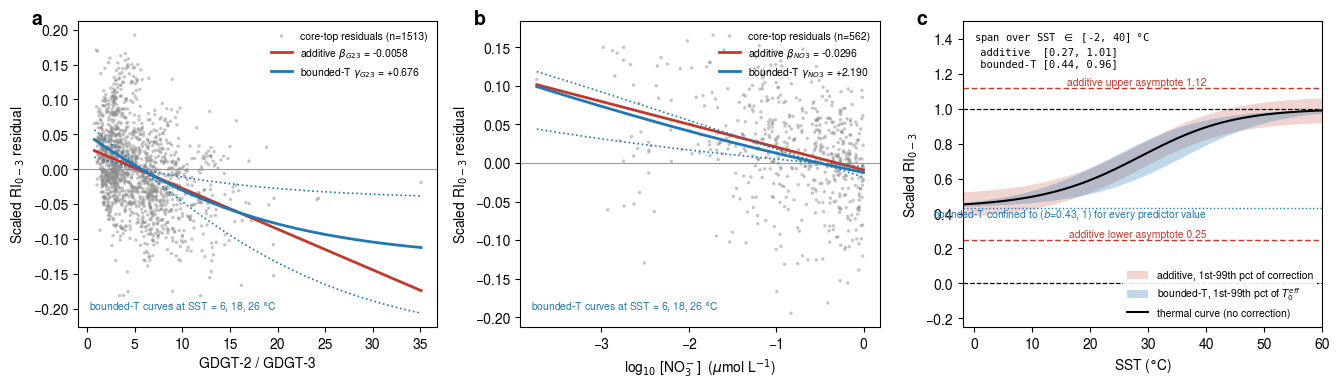

In [18]:

fpath = os.path.join(local_github_path, 'figures/manuscript/finalized/supplementary')
fname = 'figS11_ODR_regression_dilution_t0shift.pdf'

fig, axs = plot_additive_vs_t0shift(res_add, res_bnd, estimator='ols',
                                     savepath=os.path.join(fpath, fname))

wrote /home/rrattan/Documents/GitHub/TEXAS/figures/manuscript/finalized/main-text/fig6_ODR_regression_dilution_boundedT.pdf


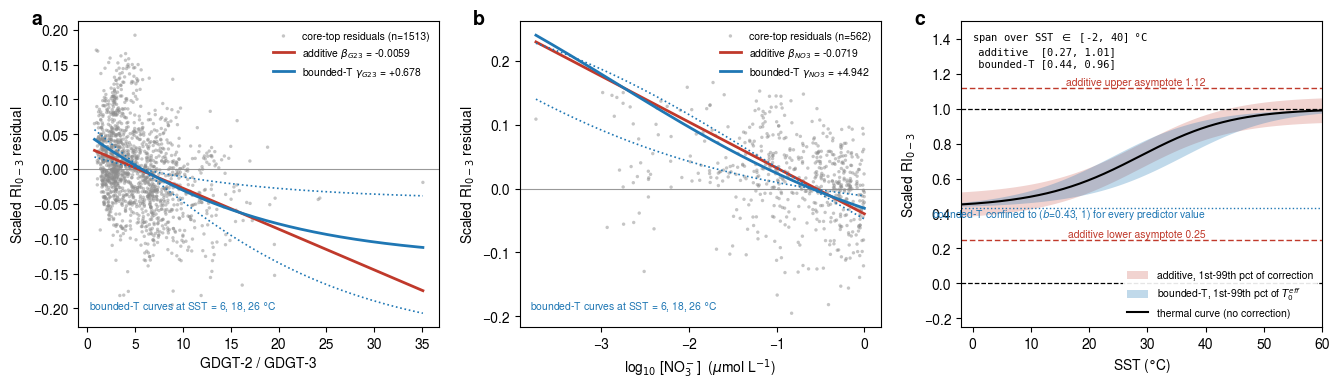

In [19]:

fpath = os.path.join(local_github_path, 'figures/manuscript/finalized/supplementary')
fname = 'figS11_ODR_regression_dilution_t0shift.pdf'

fig, axs = plot_additive_vs_t0shift(res_add, res_bnd, estimator='odr',
                                     savepath=os.path.join(fpath, fname))


# 9. Machine-readable summary

One row per (parameterization, fitting route, estimator, model), for the response letter and
for whoever has to check these numbers later.

In [14]:

def summary_table(results):
    """results: {label: res_dict} -> tidy DataFrame."""
    rows = []
    for label, r in results.items():
        rows.append(dict(run=label, parameterization=r['parameterization'],
                         beta_fit=r['beta_fit'], estimator='-', model='T only',
                         r2=r['r2_base'], rmse=r['rmse_base'], coef_g23=np.nan,
                         coef_no3=np.nan, n=r['n_coretop']))
        for est in ('ols', 'odr'):
            for m in ('G23', 'NO3', 'Both'):
                d = r[est].get(m)
                if d is None:
                    continue
                rows.append(dict(run=label, parameterization=r['parameterization'],
                                 beta_fit=r['beta_fit'], estimator=est, model=m,
                                 r2=d['r2'], rmse=d['rmse'],
                                 coef_g23=d['cG'], coef_no3=d['cN'], n=r['n_coretop']))
    return pd.DataFrame(rows)


summary = summary_table({
    'additive/twostep':  res_add,
    't0shift/twostep':  res_bnd,
    'additive/joint':    res_add_joint,
    't0shift/joint':    res_bnd_joint,
})
summary

,run,parameterization,beta_fit,estimator,model,r2,rmse,coef_g23,coef_no3,n
0,additive/twostep,additive,twostep,-,T only,0.746868,0.057535,NaN,NaN,1513
1,additive/twostep,additive,twostep,ols,G23,0.777372,0.053957,-0.005850,NaN,1513
2,additive/twostep,additive,twostep,ols,NO3,0.768682,0.055000,NaN,-0.029572,1513
3,additive/twostep,additive,twostep,ols,Both,0.800045,0.051135,-0.005932,-0.030153,1513
4,additive/twostep,additive,twostep,odr,G23,0.777371,0.053957,-0.005863,NaN,1513
5,additive/twostep,additive,twostep,odr,NO3,0.699808,0.062655,NaN,-0.071886,1513
6,additive/twostep,additive,twostep,odr,Both,0.742644,0.058013,-0.008266,-0.066907,1513
7,boundedT/twostep,boundedT,twostep,-,T only,0.746868,0.057535,NaN,NaN,1513
8,boundedT/twostep,boundedT,twostep,ols,G23,0.789264,0.052496,0.675513,NaN,1513
9,boundedT/twostep,boundedT,twostep,ols,NO3,0.772170,0.054583,NaN,2.190124,1513


In [15]:

outpath = os.path.join(local_github_path, 'data/spreadsheets',
                       'ds_frequentist_additive_vs_t0shift_summary.csv')
summary.to_csv(outpath, index=False)
print('wrote', outpath)

wrote /home/rrattan/Documents/GitHub/TEXAS/data/spreadsheets/ds_frequentist_additive_vs_boundedT_summary.csv
